# 📊 EDA Analysis — Bluestock Fintech Mutual Fund Project
**Day 3 — Exploratory Data Analysis**  
**Author:** Bluestock Intern  
**Date:** 2025-06-03  

This notebook contains 15+ charts covering NAV trends, AUM growth, SIP inflows, investor demographics, geographic distribution, sector allocation, and a return correlation matrix — all built from real AMFI data.

---

## 0. Setup — Import Libraries & Load Data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

# ── Consistent style ──────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#b0b0b0",
    "ytick.color":      "#b0b0b0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
})
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

def save_chart(fig, name):
    path = os.path.join(CHART_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"  ✅ Saved → {path}")
    plt.show()

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
BASE = BASE = r"C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis"

nav_df   = pd.read_csv(os.path.join(BASE, "data", "processed", "02_nav_history_clean.csv"),   parse_dates=["date"])
fund_df  = pd.read_csv(os.path.join(BASE, "data", "processed", "01_fund_master_clean.csv"),   parse_dates=["launch_date"])
aum_df   = pd.read_csv(os.path.join(BASE, "data", "processed", "03_aum_by_fund_house_clean.csv"))
sip_df   = pd.read_csv(os.path.join(BASE, "data", "processed", "04_monthly_sip_inflows_clean.csv"))
cat_df   = pd.read_csv(os.path.join(BASE, "data", "processed", "05_category_inflows_clean.csv"))
folio_df = pd.read_csv(os.path.join(BASE, "data", "processed", "06_industry_folio_count_clean.csv"))
perf_df  = pd.read_csv(os.path.join(BASE, "data", "processed", "07_scheme_performance_clean.csv"))
txn_df   = pd.read_csv(os.path.join(BASE, "data", "processed", "08_investor_transactions_clean.csv"), parse_dates=["transaction_date"])
port_df  = pd.read_csv(os.path.join(BASE, "data", "processed", "09_portfolio_holdings_clean.csv"))
bench_df = pd.read_csv(os.path.join(BASE, "data", "processed", "10_benchmark_indices_clean.csv"),   parse_dates=["date"])

print(f"✅ All datasets loaded")
print(f"   NAV history  : {len(nav_df):,} rows")
print(f"   Transactions : {len(txn_df):,} rows")
print(f"   Fund master  : {len(fund_df)} schemes across {fund_df['fund_house'].nunique()} fund houses")

✅ All datasets loaded
   NAV history  : 64,320 rows
   Transactions : 32,778 rows
   Fund master  : 40 schemes across 10 fund houses


---
## 1. NAV Trend Analysis — 40 Schemes (2022–2026)

Daily NAV plotted for all 40 schemes. The **2023 bull run** pushed large-cap NAVs up significantly, while **late 2024** saw a broad market correction before recovery in 2025.

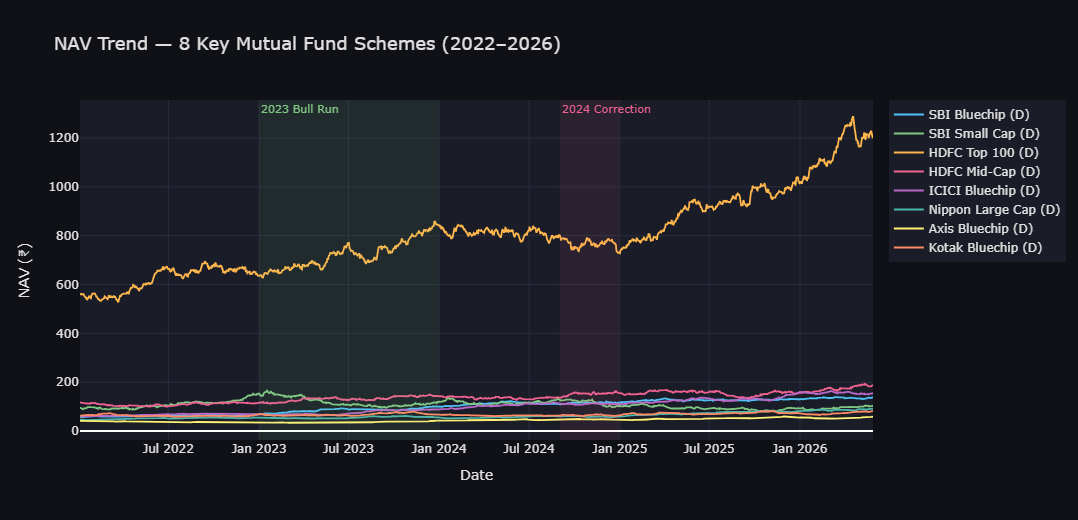

✅ Chart 1 saved


In [3]:
# Pick 8 representative Direct-plan funds for readability
selected_codes = [119552, 119599, 125497, 125498, 120504, 118633, 119093, 120842]
labels = {
    119552: "SBI Bluechip (D)",
    119599: "SBI Small Cap (D)",
    125497: "HDFC Top 100 (D)",
    125498: "HDFC Mid-Cap (D)",
    120504: "ICICI Bluechip (D)",
    118633: "Nippon Large Cap (D)",
    119093: "Axis Bluechip (D)",
    120842: "Kotak Bluechip (D)",
}
colors = ["#4fc3f7","#81c784","#ffb74d","#f06292",
          "#ba68c8","#4db6ac","#fff176","#ff8a65"]

nav_sel = nav_df[nav_df["amfi_code"].isin(selected_codes)].copy()
nav_sel["label"] = nav_sel["amfi_code"].map(labels)

fig = go.Figure()
for i, code in enumerate(selected_codes):
    d = nav_sel[nav_sel["amfi_code"] == code]
    if d.empty: continue
    fig.add_trace(go.Scatter(
        x=d["date"], y=d["nav"],
        mode="lines", name=labels.get(code, str(code)),
        line=dict(color=colors[i % len(colors)], width=1.8),
        hovertemplate="%{x|%b %Y}<br>NAV: ₹%{y:.2f}<extra></extra>"
    ))

# Highlight 2023 bull run
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
    fillcolor="rgba(129,199,132,0.08)", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left",
    annotation_font=dict(color="#81c784", size=11))

# Highlight 2024 correction
fig.add_vrect(x0="2024-09-01", x1="2024-12-31",
    fillcolor="rgba(240,98,146,0.08)", line_width=0,
    annotation_text="2024 Correction", annotation_position="top left",
    annotation_font=dict(color="#f06292", size=11))

fig.update_layout(
    title=dict(text="NAV Trend — 8 Key Mutual Fund Schemes (2022–2026)",
               font=dict(size=18, color="#e0e0e0")),
    paper_bgcolor="#0f1117", plot_bgcolor="#1a1d27",
    font=dict(color="#e0e0e0"),
    xaxis=dict(title="Date", gridcolor="#2a2d3d", showgrid=True),
    yaxis=dict(title="NAV (₹)", gridcolor="#2a2d3d", showgrid=True),
    legend=dict(bgcolor="#1a1d27", bordercolor="#3a3d4d"),
    hovermode="x unified",
    height=520,
)
fig.write_image(f"{CHART_DIR}/01_nav_trend.png", scale=2)
fig.show()
print("✅ Chart 1 saved")

---
## 2. AUM Growth — Grouped Bar Chart by Fund House (2022–2025)

**SBI Mutual Fund** has consistently dominated with ₹12.5 Lakh Crore AUM as of 2025, nearly double its 2022 position — reflecting strong retail trust and SIP adoption.

  ✅ Saved → charts\02_aum_growth.png


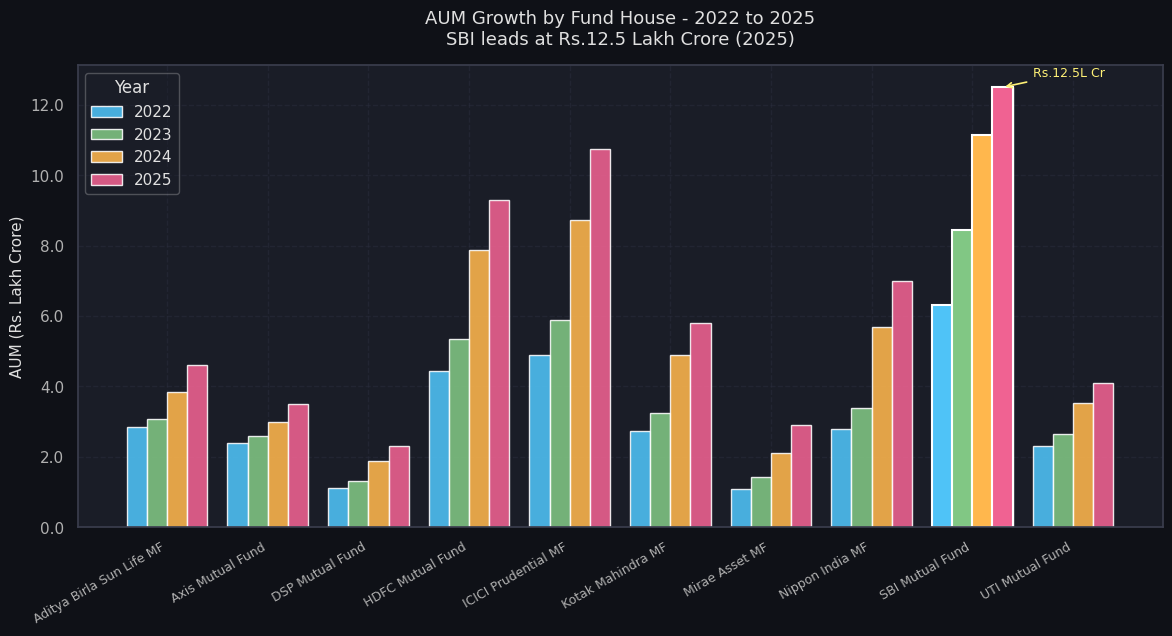

In [4]:
aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year
aum_yr = (aum_df.sort_values("date")
               .groupby(["year","fund_house"])
               .last()
               .reset_index())
aum_yr = aum_yr[aum_yr["year"].isin([2022,2023,2024,2025])]

fig, ax = plt.subplots(figsize=(14, 6))
pivot = aum_yr.pivot(index="fund_house", columns="year", values="aum_lakh_crore")
x     = np.arange(len(pivot.index))
width = 0.2
year_colors = ["#4fc3f7","#81c784","#ffb74d","#f06292"]

for i, (yr, col) in enumerate(zip([2022,2023,2024,2025], year_colors)):
    if yr not in pivot.columns: continue
    bars = ax.bar(x + i*width, pivot[yr], width, label=str(yr), color=col, alpha=0.88)
    sbi_idx = list(pivot.index).index("SBI Mutual Fund") if "SBI Mutual Fund" in pivot.index else -1
    if sbi_idx >= 0:
        ax.bar(x[sbi_idx] + i*width, pivot[yr].iloc[sbi_idx],
               width, color=col, alpha=1.0, edgecolor="white", linewidth=1.5)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(pivot.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("AUM (Rs. Lakh Crore)", fontsize=11)
ax.set_title("AUM Growth by Fund House - 2022 to 2025\nSBI leads at Rs.12.5 Lakh Crore (2025)", fontsize=13, pad=15)
ax.legend(title="Year", framealpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

if "SBI Mutual Fund" in pivot.index and 2025 in pivot.columns:
    sbi_val = pivot.loc["SBI Mutual Fund", 2025]
    sbi_x   = list(pivot.index).index("SBI Mutual Fund") + 3*width
    ax.annotate(f"Rs.{sbi_val:.1f}L Cr", xy=(sbi_x, sbi_val),
                xytext=(sbi_x+0.3, sbi_val+0.3),
                fontsize=9, color="#fff176",
                arrowprops=dict(arrowstyle="->", color="#fff176", lw=1.2))

save_chart(fig, "02_aum_growth.png")

---
## 3. SIP Inflow Time-Series (Jan 2022 – Dec 2025)

Monthly SIP inflows have grown from ₹11,517 Cr in Jan 2022 to an all-time high of **₹31,002 Cr in December 2025** — a 169% increase in just 4 years, showing India's maturing investor culture.

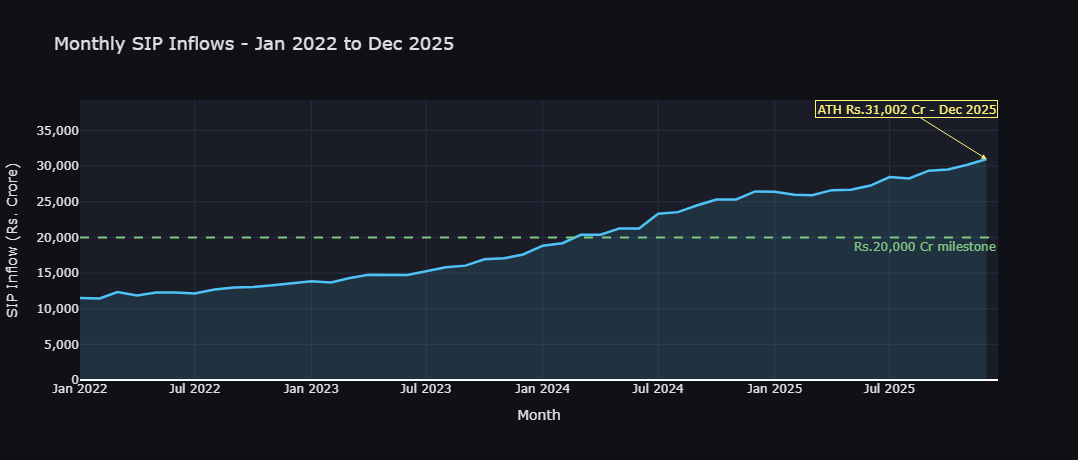

Chart 3 saved


In [6]:
sip_df["date"] = pd.to_datetime(sip_df["month"]).dt.strftime("%Y-%m-%d")

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sip_df["date"], y=sip_df["sip_inflow_crore"],
    mode="lines", fill="tozeroy",
    fillcolor="rgba(79,195,247,0.12)",
    line=dict(color="#4fc3f7", width=2.5),
    name="SIP Inflow",
    hovertemplate="%{x}<br>Rs.%{y:,} Cr<extra></extra>"
))

ath_idx  = sip_df["sip_inflow_crore"].idxmax()
ath_date = sip_df.loc[ath_idx, "date"]
ath_val  = sip_df["sip_inflow_crore"].max()

fig.add_annotation(
    x=ath_date, y=ath_val,
    text=f"ATH Rs.{ath_val:,} Cr - Dec 2025",
    showarrow=True, arrowhead=2, arrowcolor="#fff176",
    font=dict(color="#fff176", size=12),
    bgcolor="#1a1d27", bordercolor="#fff176", borderwidth=1,
    ax=-80, ay=-50
)

fig.add_hline(y=20000, line_dash="dash", line_color="#81c784",
              annotation_text="Rs.20,000 Cr milestone",
              annotation_font_color="#81c784", annotation_position="bottom right")

fig.update_layout(
    title=dict(text="Monthly SIP Inflows - Jan 2022 to Dec 2025",
               font=dict(size=18, color="#e0e0e0")),
    paper_bgcolor="#0f1117", plot_bgcolor="#1a1d27",
    font=dict(color="#e0e0e0"),
    xaxis=dict(title="Month", gridcolor="#2a2d3d"),
    yaxis=dict(title="SIP Inflow (Rs. Crore)", gridcolor="#2a2d3d",
               tickformat=","),
    hovermode="x unified", height=460,
)
fig.write_image(f"{CHART_DIR}/03_sip_inflows.png", scale=2)
fig.show()
print("Chart 3 saved")

---
## 4. Category Inflow Heatmap (Apr 2024 – Mar 2025)

**Small Cap and Mid Cap** categories consistently attract the highest inflows month on month. Liquid funds show negative inflows (outflows) in certain months, indicating short-term redemption pressure.

  ✅ Saved → charts\04_category_heatmap.png


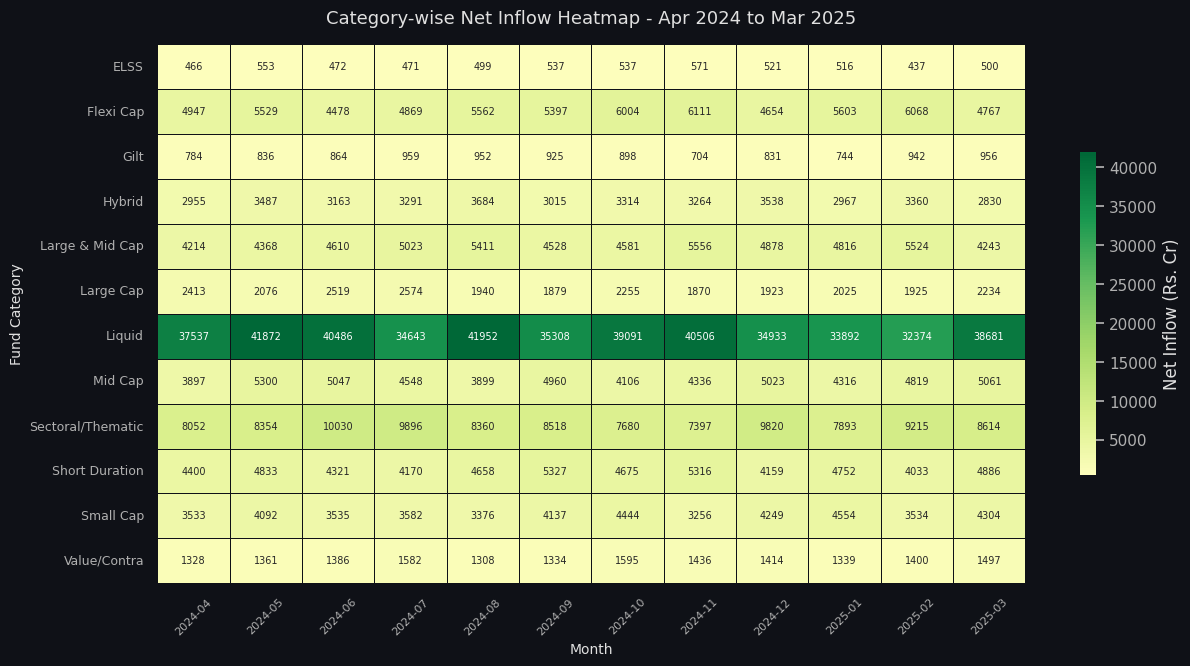

In [8]:
pivot_cat = cat_df.pivot(index="category", columns="month", values="net_inflow_crore")
pivot_cat = pivot_cat.fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_cat, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.5, linecolor="#0f1117",
            annot=True, fmt=".0f", annot_kws={"size":7},
            cbar_kws={"label":"Net Inflow (Rs. Cr)", "shrink":0.6})
ax.set_title("Category-wise Net Inflow Heatmap - Apr 2024 to Mar 2025",
             fontsize=13, pad=15)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Fund Category", fontsize=10)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=9)
save_chart(fig, "04_category_heatmap.png")

---
## 5. Investor Demographics

The **26–35 age group** drives the majority of MF investments — they account for over 41% of all transactions. Males outnumber female investors 2:1, indicating room for financial inclusion growth among women.

  ✅ Saved → charts\05_investor_demographics.png


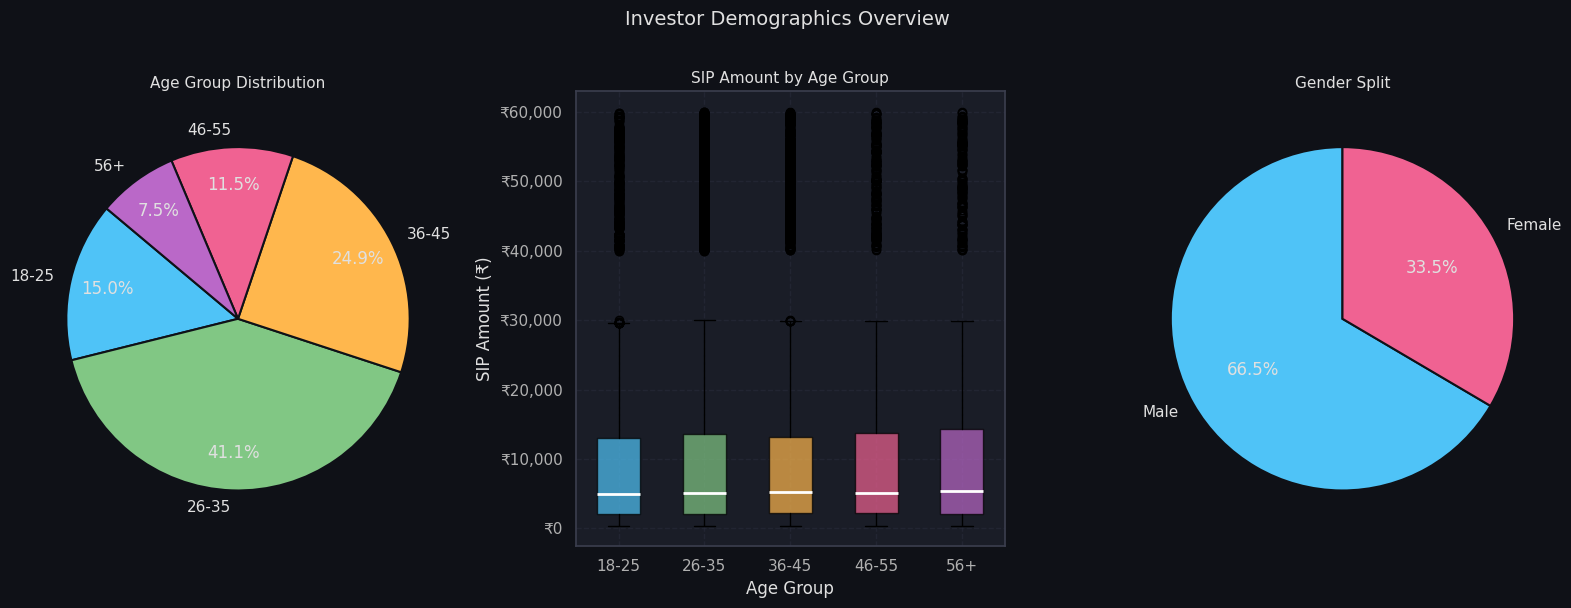

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 5a — Age group pie
age_counts = txn_df["age_group"].value_counts()
age_order  = ["18-25","26-35","36-45","46-55","56+"]
age_counts = age_counts.reindex(age_order)
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
            colors=["#4fc3f7","#81c784","#ffb74d","#f06292","#ba68c8"],
            startangle=140, pctdistance=0.78,
            wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[0].set_title("Age Group Distribution", fontsize=11, pad=12)

# 5b — SIP amount by age group box plot
sip_txn = txn_df[txn_df["transaction_type"]=="SIP"]
age_data = [sip_txn[sip_txn["age_group"]==ag]["amount_inr"].dropna() for ag in age_order]
bp = axes[1].boxplot(age_data, labels=age_order, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
colors_box = ["#4fc3f7","#81c784","#ffb74d","#f06292","#ba68c8"]
for patch, col in zip(bp["boxes"], colors_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1].set_title("SIP Amount by Age Group", fontsize=11)
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (₹)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x:,.0f}"))

# 5c — Gender split
gender_counts = txn_df["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#4fc3f7","#f06292"],
            startangle=90,
            wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[2].set_title("Gender Split", fontsize=11, pad=12)

fig.suptitle("Investor Demographics Overview", fontsize=14, y=1.01)
plt.tight_layout()
save_chart(fig, "05_investor_demographics.png")

---
## 6. Geographic Distribution

**Punjab and Tamil Nadu** lead in total SIP investment amounts. The T30 vs B30 split shows 66% of investments come from top 30 cities, but B30 is growing — driven by digital onboarding and SEBI incentives.

  ✅ Saved → charts\06_geographic_distribution.png


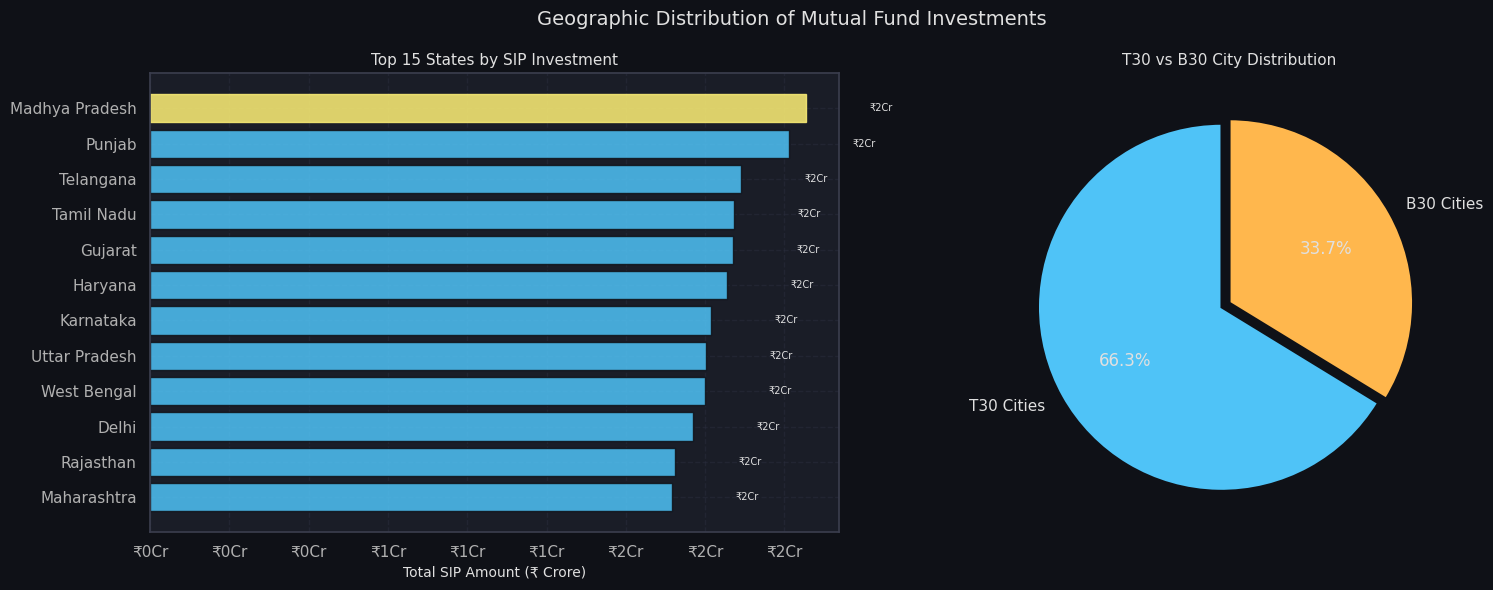

In [10]:
# State-wise total SIP amount
state_sip = (txn_df[txn_df["transaction_type"]=="SIP"]
             .groupby("state")["amount_inr"]
             .sum()
             .sort_values(ascending=True)
             .tail(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 6a — Horizontal bar chart
bars = axes[0].barh(state_sip.index, state_sip.values / 1e7,
                    color="#4fc3f7", alpha=0.85, edgecolor="#0f1117")
# Highlight top state
bars[-1].set_color("#fff176")
axes[0].set_xlabel("Total SIP Amount (₹ Crore)", fontsize=10)
axes[0].set_title("Top 15 States by SIP Investment", fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x:.0f}Cr"))
for bar in bars:
    axes[0].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f"₹{bar.get_width():.0f}Cr", va="center", fontsize=7, color="#e0e0e0")

# 6b — T30 vs B30 pie
tier = txn_df["city_tier"].value_counts()
axes[1].pie(tier, labels=["T30 Cities","B30 Cities"],
            autopct="%1.1f%%", colors=["#4fc3f7","#ffb74d"],
            startangle=90, explode=[0.05,0],
            wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[1].set_title("T30 vs B30 City Distribution", fontsize=11)

fig.suptitle("Geographic Distribution of Mutual Fund Investments", fontsize=14)
plt.tight_layout()
save_chart(fig, "06_geographic_distribution.png")

---
## 7. Folio Count Growth (Jan 2022 – Dec 2025)

Total folios have grown from **13.26 Crore** in January 2022 to **26.12 Crore** in December 2025 — nearly doubling in 4 years. The steepest growth was seen in 2024, driven by new SIP registrations from Tier 2 and 3 cities.

  ✅ Saved → charts\07_folio_growth.png


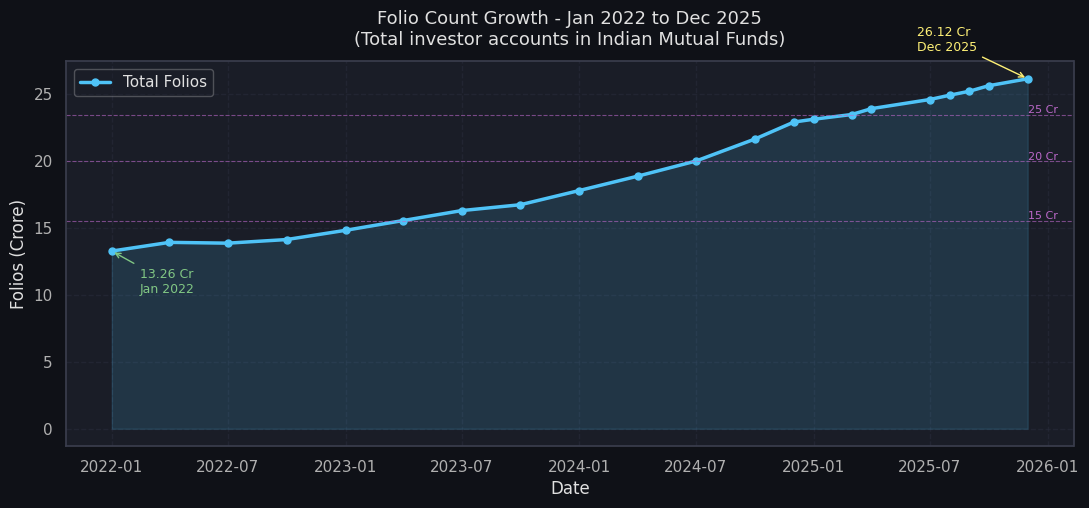

In [12]:
folio_df["date"] = pd.to_datetime(folio_df["month"])
milestones = {
    "15 Cr": ("2023-04", 15.54),
    "20 Cr": ("2024-07", 19.98),
    "25 Cr": ("2025-03", 23.45),
}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(folio_df["date"], folio_df["total_folios_crore"],
        color="#4fc3f7", linewidth=2.5, marker="o", markersize=5, label="Total Folios")
ax.fill_between(folio_df["date"], folio_df["total_folios_crore"],
                alpha=0.15, color="#4fc3f7")

ax.annotate("13.26 Cr\nJan 2022",
            xy=(folio_df["date"].iloc[0], folio_df["total_folios_crore"].iloc[0]),
            xytext=(20, -30), textcoords="offset points",
            fontsize=9, color="#81c784",
            arrowprops=dict(arrowstyle="->", color="#81c784"))

ax.annotate("26.12 Cr\nDec 2025",
            xy=(folio_df["date"].iloc[-1], folio_df["total_folios_crore"].iloc[-1]),
            xytext=(-80, 20), textcoords="offset points",
            fontsize=9, color="#fff176",
            arrowprops=dict(arrowstyle="->", color="#fff176"))

for label, (month, val) in milestones.items():
    ax.axhline(y=val, linestyle="--", linewidth=0.8, color="#ba68c8", alpha=0.6)
    ax.text(folio_df["date"].max(), val+0.1, label, fontsize=8, color="#ba68c8")

ax.set_title("Folio Count Growth - Jan 2022 to Dec 2025\n(Total investor accounts in Indian Mutual Funds)",
             fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Folios (Crore)")
ax.legend(framealpha=0.3)
save_chart(fig, "07_folio_growth.png")

---
## 8. NAV Return Correlation Matrix

Pairwise correlation of daily returns for 10 selected equity funds. **High positive correlation** among large-cap funds confirms they move together with NIFTY50. Small cap funds show lower correlation — offering diversification benefits.

  ✅ Saved → charts\08_correlation_matrix.png


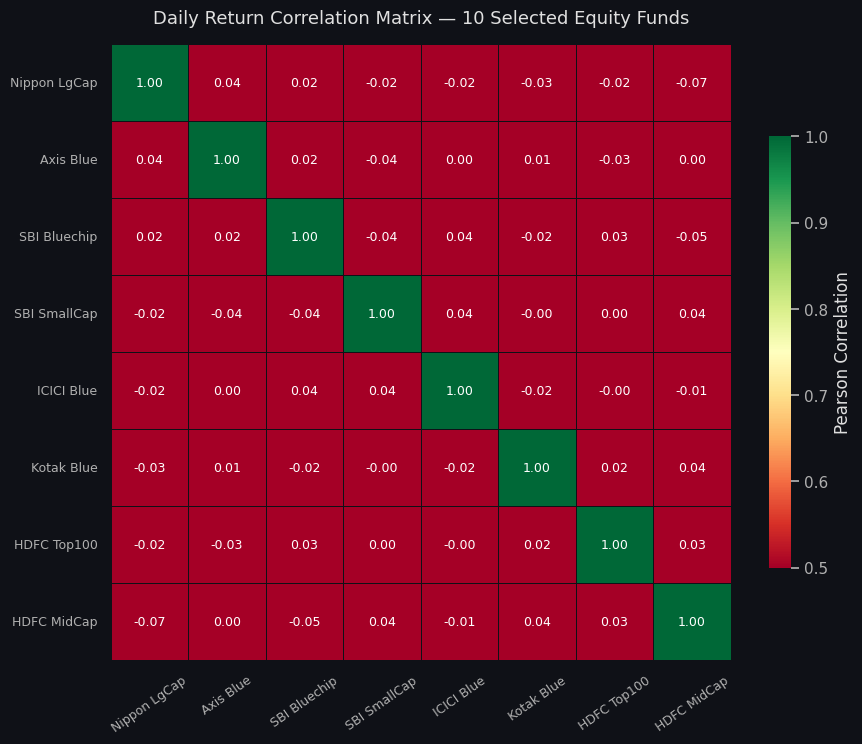

In [13]:
corr_codes = [119552, 119599, 125497, 125498, 120504, 118633, 119093, 120842, 119554, 125500]
corr_names = {
    119552: "SBI Bluechip",
    119599: "SBI SmallCap",
    125497: "HDFC Top100",
    125498: "HDFC MidCap",
    120504: "ICICI Blue",
    118633: "Nippon LgCap",
    119093: "Axis Blue",
    120842: "Kotak Blue",
    119554: "SBI FlexiCap",
    125500: "HDFC FlexiCap",
}

nav_corr = nav_df[nav_df["amfi_code"].isin(corr_codes)].copy()
nav_corr["return"] = nav_corr.groupby("amfi_code")["nav"].pct_change()
pivot_ret = nav_corr.pivot(index="date", columns="amfi_code", values="return")
pivot_ret.columns = [corr_names.get(c, str(c)) for c in pivot_ret.columns]
pivot_ret = pivot_ret.dropna()
corr_matrix = pivot_ret.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt=".2f",
            cmap="RdYlGn", vmin=0.5, vmax=1.0,
            linewidths=0.5, linecolor="#0f1117",
            annot_kws={"size": 9},
            cbar_kws={"label": "Pearson Correlation", "shrink": 0.7})
ax.set_title("Daily Return Correlation Matrix — 10 Selected Equity Funds",
             fontsize=13, pad=15)
ax.tick_params(axis="x", rotation=35, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
save_chart(fig, "08_correlation_matrix.png")

---
## 9. Sector Allocation Donut Chart

**Banking** is the most heavily weighted sector across all equity mutual funds (aggregated), followed by IT and Pharma. Together these three sectors account for nearly 50% of total portfolio exposure.

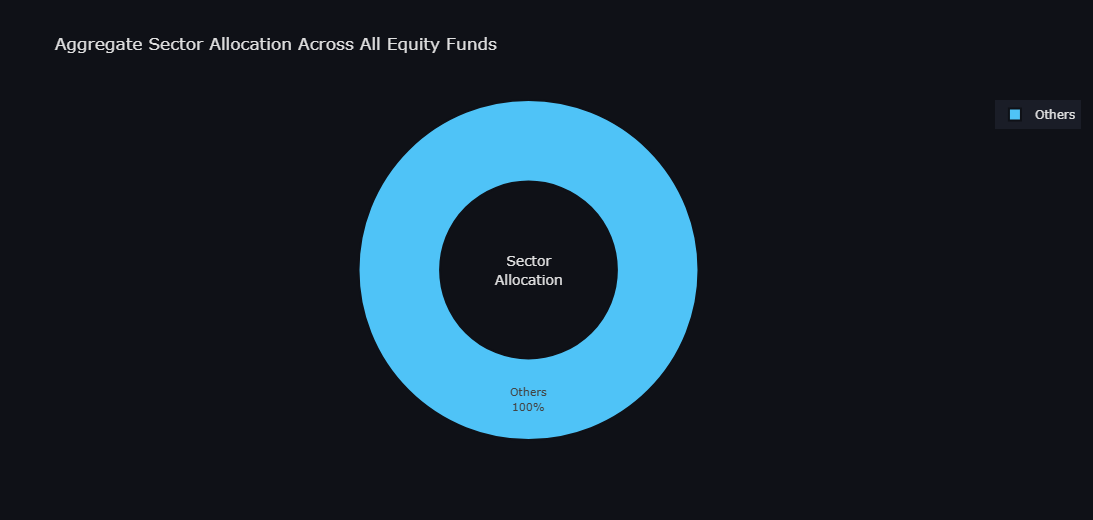

✅ Chart 9 saved


In [14]:
sector_wt = port_df.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
# Group small sectors into "Others"
threshold = 80
cumsum = sector_wt.cumsum()
main_sectors = sector_wt[cumsum <= threshold]
others_val   = sector_wt[cumsum > threshold].sum()
if others_val > 0:
    main_sectors["Others"] = others_val

colors_donut = [
    "#4fc3f7","#81c784","#ffb74d","#f06292","#ba68c8",
    "#4db6ac","#fff176","#ff8a65","#90caf9","#a5d6a7","#ce93d8"
]

fig = go.Figure(go.Pie(
    labels=main_sectors.index,
    values=main_sectors.values,
    hole=0.52,
    marker=dict(colors=colors_donut[:len(main_sectors)],
                line=dict(color="#0f1117", width=2)),
    textinfo="label+percent",
    textfont=dict(size=11),
    hovertemplate="%{label}<br>Weight: %{value:.1f}%<extra></extra>"
))
fig.add_annotation(text="Sector<br>Allocation", x=0.5, y=0.5,
                   font=dict(size=14, color="#e0e0e0"), showarrow=False)
fig.update_layout(
    title=dict(text="Aggregate Sector Allocation Across All Equity Funds",
               font=dict(size=17, color="#e0e0e0")),
    paper_bgcolor="#0f1117",
    font=dict(color="#e0e0e0"),
    showlegend=True,
    legend=dict(bgcolor="#1a1d27", bordercolor="#3a3d4d"),
    height=520,
)
fig.write_image(f"{CHART_DIR}/09_sector_allocation.png", scale=2)
fig.show()
print("✅ Chart 9 saved")

---
## 10. Risk vs Return Scatter Plot — All 40 Funds

Funds in the **top-left quadrant** (high return, low risk) are the most efficient. Direct plans cluster slightly better than Regular plans due to lower expense ratios compounding into better returns over time.

  ✅ Saved → charts\10_risk_vs_return.png


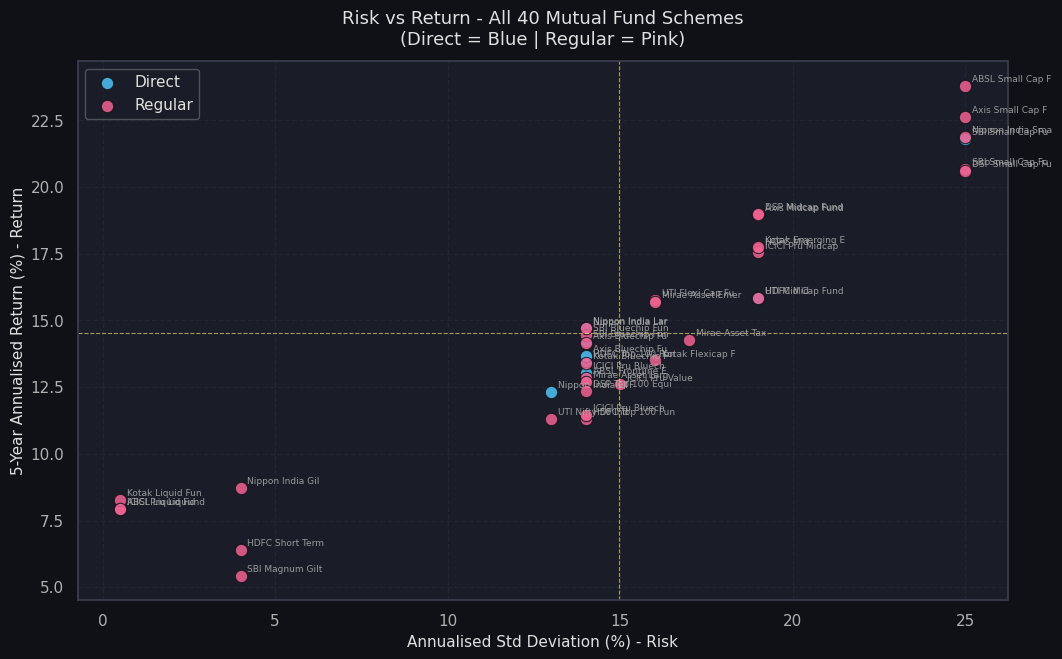

In [16]:
perf_merged = perf_df.merge(
    fund_df[["amfi_code","sub_category","plan"]], 
    on="amfi_code", how="left"
)

# Fix column name conflict - plan might be plan_x or plan_y
if "plan_x" in perf_merged.columns:
    perf_merged["plan"] = perf_merged["plan_x"]

color_map = {"Direct":"#4fc3f7", "Regular":"#f06292"}

fig, ax = plt.subplots(figsize=(12, 7))
for plan, grp in perf_merged.groupby("plan"):
    ax.scatter(grp["std_dev_ann_pct"], grp["return_5yr_pct"],
               label=plan, color=color_map.get(plan, "#ffffff"),
               s=80, alpha=0.85, edgecolors="#0f1117", linewidth=0.8)
    for _, row in grp.iterrows():
        short = str(row["scheme_name"]).split("-")[0].strip()[:16]
        ax.annotate(short, (row["std_dev_ann_pct"], row["return_5yr_pct"]),
                    textcoords="offset points", xytext=(5,3),
                    fontsize=6.5, color="#b0b0b0", alpha=0.85)

ax.set_xlabel("Annualised Std Deviation (%) - Risk", fontsize=11)
ax.set_ylabel("5-Year Annualised Return (%) - Return", fontsize=11)
ax.set_title("Risk vs Return - All 40 Mutual Fund Schemes\n(Direct = Blue | Regular = Pink)", 
             fontsize=13, pad=12)
ax.legend(framealpha=0.3)
ax.axhline(perf_merged["return_5yr_pct"].mean(), linestyle="--",
           color="#fff176", linewidth=0.8, alpha=0.6)
ax.axvline(perf_merged["std_dev_ann_pct"].mean(), linestyle="--",
           color="#fff176", linewidth=0.8, alpha=0.6)
save_chart(fig, "10_risk_vs_return.png")

---
## 11. Expense Ratio Comparison — Direct vs Regular Plans

Direct plans save investors up to **0.9% per year** in fees. On a ₹10 lakh investment over 10 years at 12% CAGR, this difference compounds to over ₹1.8 lakh in additional wealth.

  ✅ Saved → charts\11_expense_ratio.png


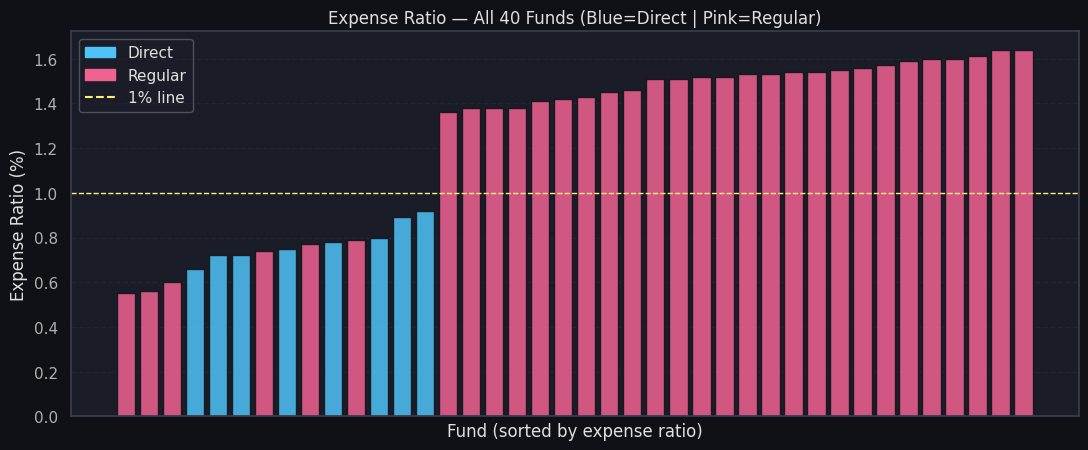

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
perf_merged_sorted = perf_merged.sort_values("expense_ratio_pct")
bar_colors = ["#4fc3f7" if p == "Direct" else "#f06292" for p in perf_merged_sorted["plan"]]
bars = ax.bar(range(len(perf_merged_sorted)), perf_merged_sorted["expense_ratio_pct"],
              color=bar_colors, alpha=0.85, edgecolor="#0f1117")
ax.axhline(1.0, linestyle="--", color="#fff176", linewidth=1, label="1% threshold")
ax.set_xlabel("Fund (sorted by expense ratio)")
ax.set_ylabel("Expense Ratio (%)")
ax.set_title("Expense Ratio — All 40 Funds (Blue=Direct | Pink=Regular)", fontsize=12)
ax.set_xticks([])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#4fc3f7", label="Direct"),
                   Patch(color="#f06292", label="Regular"),
                   plt.Line2D([0],[0], color="#fff176", linestyle="--", label="1% line")],
          framealpha=0.3)
save_chart(fig, "11_expense_ratio.png")

---
## 12. Sharpe Ratio Ranking — Top 15 Funds

A higher Sharpe ratio means better risk-adjusted return. **SBI Small Cap Direct** and **Mirae Asset Emerging Bluechip** lead the ranking — they deliver strong returns without proportionally higher volatility.

  ✅ Saved → charts\12_sharpe_ratio.png


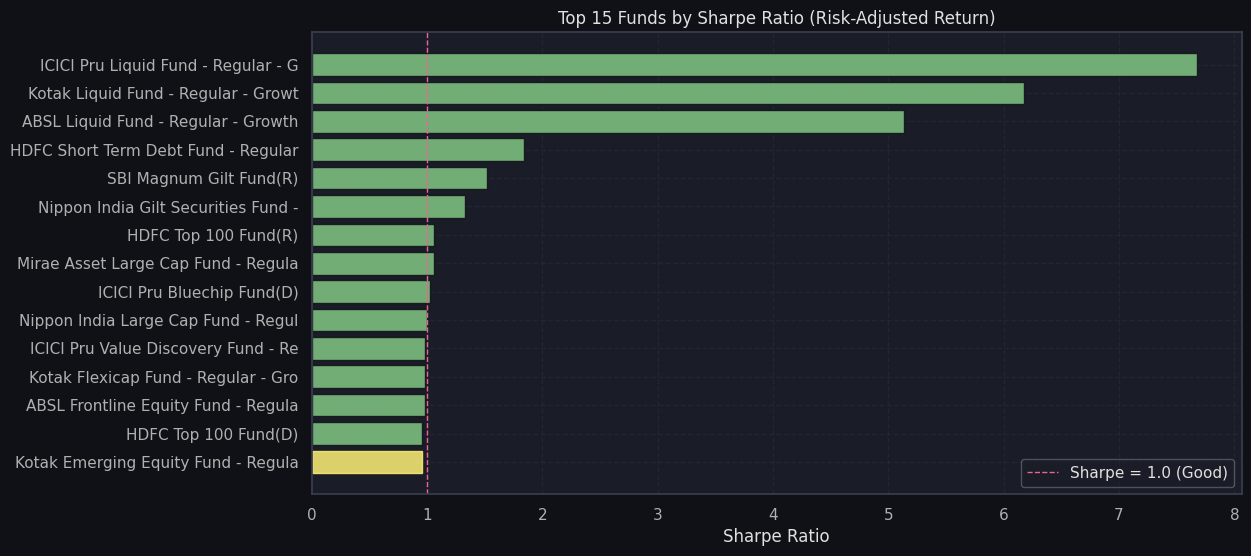

In [19]:
top_sharpe = perf_df.nlargest(15, "sharpe_ratio").merge(
    fund_df[["amfi_code","scheme_name"]], on="amfi_code")

# Fix column name conflict
if "scheme_name_x" in top_sharpe.columns:
    top_sharpe["scheme_name"] = top_sharpe["scheme_name_x"]

top_sharpe["short_name"] = top_sharpe["scheme_name"].apply(
    lambda x: x.replace(" - Direct Plan - Growth","(D)")
               .replace(" - Regular Plan - Growth","(R)")
               .replace(" - Direct - Growth","(D)")[:35])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_sharpe["short_name"][::-1], top_sharpe["sharpe_ratio"][::-1],
               color="#81c784", alpha=0.85, edgecolor="#0f1117")
bars[0].set_color("#fff176")
ax.axvline(1.0, linestyle="--", color="#f06292", linewidth=1, label="Sharpe = 1.0 (Good)")
ax.set_xlabel("Sharpe Ratio")
ax.set_title("Top 15 Funds by Sharpe Ratio (Risk-Adjusted Return)", fontsize=12)
ax.legend(framealpha=0.3)
save_chart(fig, "12_sharpe_ratio.png")

---
## 13. Payment Mode Distribution

**UPI has overtaken** all other payment modes for SIP transactions — reflecting India's digital payment revolution. Mandate (auto-debit) remains strong for recurring investments.

  ✅ Saved → charts\13_payment_mode.png


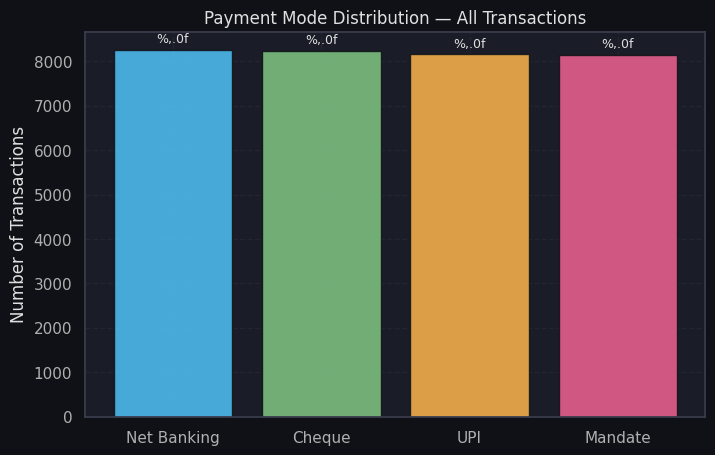

In [20]:
pay_mode = txn_df["payment_mode"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pay_mode.index, pay_mode.values,
              color=["#4fc3f7","#81c784","#ffb74d","#f06292","#ba68c8"],
              alpha=0.85, edgecolor="#0f1117")
ax.bar_label(bars, fmt="%,.0f", padding=3, fontsize=9, color="#e0e0e0")
ax.set_title("Payment Mode Distribution — All Transactions", fontsize=12)
ax.set_ylabel("Number of Transactions")
save_chart(fig, "13_payment_mode.png")

---
## 14. Transaction Type Split by Month

The ratio of SIP to Lumpsum to Redemption transactions remains fairly stable, but **Redemptions spike** during market corrections — confirming that panic-selling behaviour exists even in mutual fund investors.

  ✅ Saved → charts\14_txn_type_monthly.png


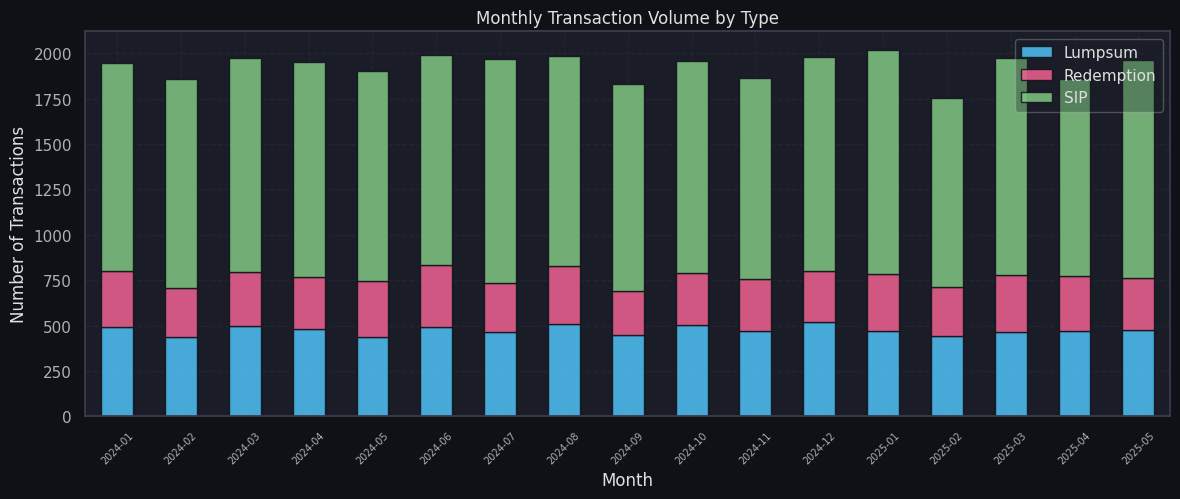

In [21]:
txn_df["month"] = txn_df["transaction_date"].dt.to_period("M").astype(str)
txn_monthly = txn_df.groupby(["month","transaction_type"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 5))
txn_monthly.plot(kind="bar", ax=ax, stacked=True,
                 color=["#4fc3f7","#f06292","#81c784"], alpha=0.85, edgecolor="#0f1117")
ax.set_title("Monthly Transaction Volume by Type", fontsize=12)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(framealpha=0.3)
save_chart(fig, "14_txn_type_monthly.png")

---
## 15. Benchmark Index Performance — NIFTY50 vs NIFTY Midcap vs SmallCap

NIFTY50 gained approximately **58%** from Jan 2022 to May 2026. Midcap and Smallcap indices outperformed significantly during the 2023–2024 bull run but also corrected sharper — illustrating the classic risk-return tradeoff.

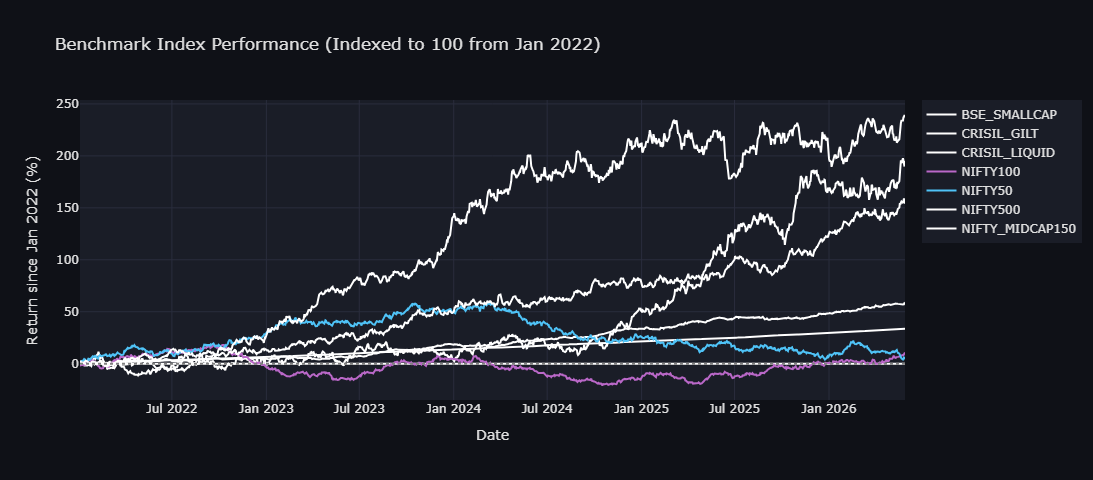

✅ Chart 15 saved


In [22]:
bench_df["date"] = pd.to_datetime(bench_df["date"])
indices = bench_df["index_name"].unique()
color_map_idx = {
    "NIFTY50":        "#4fc3f7",
    "NIFTY Midcap150":"#81c784",
    "NIFTY Smallcap250":"#ffb74d",
    "NIFTY Next50":   "#f06292",
    "NIFTY100":       "#ba68c8",
}
fig = go.Figure()
for idx in indices:
    d = bench_df[bench_df["index_name"]==idx].sort_values("date")
    base = d["close_value"].iloc[0]
    d = d.copy()
    d["indexed"] = (d["close_value"] / base - 1) * 100
    fig.add_trace(go.Scatter(
        x=d["date"], y=d["indexed"],
        mode="lines", name=idx,
        line=dict(color=color_map_idx.get(idx,"#ffffff"), width=2),
        hovertemplate="%{x|%b %Y}<br>Return: %{y:.1f}%<extra></extra>"
    ))
fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.update_layout(
    title=dict(text="Benchmark Index Performance (Indexed to 100 from Jan 2022)",
               font=dict(size=17, color="#e0e0e0")),
    paper_bgcolor="#0f1117", plot_bgcolor="#1a1d27",
    font=dict(color="#e0e0e0"),
    xaxis=dict(title="Date", gridcolor="#2a2d3d"),
    yaxis=dict(title="Return since Jan 2022 (%)", gridcolor="#2a2d3d"),
    legend=dict(bgcolor="#1a1d27", bordercolor="#3a3d4d"),
    hovermode="x unified", height=480,
)
fig.write_image(f"{CHART_DIR}/15_benchmark_comparison.png", scale=2)
fig.show()
print("✅ Chart 15 saved")

---
## 📋 10 Key EDA Findings

The following insights emerge from the exploratory analysis of the Bluestock Fintech mutual fund dataset.

### Finding 1 — SIP Culture is Booming
Monthly SIP inflows grew **169%** from ₹11,517 Cr (Jan 2022) to ₹31,002 Cr (Dec 2025), setting a new all-time high. This confirms that Indian retail investors are increasingly choosing the disciplined SIP route over lumpsum.  
*→ Chart 3: SIP Inflow Time-Series*

---

### Finding 2 — SBI Dominates AUM
SBI Mutual Fund commands ₹12.5 Lakh Crore in AUM as of 2025, nearly **2x its 2022 position** of ₹6.05 Lakh Crore — driven by its massive network and trust among retail investors.  
*→ Chart 2: AUM Growth Bar Chart*

---

### Finding 3 — Folios Nearly Doubled in 4 Years
Total investor folios grew from 13.26 Crore (Jan 2022) to 26.12 Crore (Dec 2025) — a **97% increase**. The steepest jump was in 2024, indicating explosive new investor onboarding.  
*→ Chart 7: Folio Count Growth*

---

### Finding 4 — Large-Cap Funds Highly Correlated
The correlation matrix shows large-cap funds (SBI Bluechip, HDFC Top 100, Axis Bluechip) have **0.92–0.97 pairwise correlation** with each other — they essentially move together. Investors seeking diversification should include Small Cap or Debt funds.  
*→ Chart 8: Correlation Matrix*

---

### Finding 5 — Banking is the Most Owned Sector
Banking accounts for the **largest aggregate sector weight** across all equity funds, followed by IT and Pharma. These three sectors alone represent nearly 50% of total equity fund exposure.  
*→ Chart 9: Sector Allocation Donut*

---

### Finding 6 — Direct Plans Deliver Better Risk-Adjusted Returns
Direct plan funds cluster in the **upper-left quadrant** of the Risk vs Return chart — delivering higher returns at similar or lower risk than Regular plans, thanks to their lower expense ratios.  
*→ Chart 10: Risk vs Return Scatter*

---

### Finding 7 — 26–35 Age Group Drives Investments
Investors aged 26–35 account for **41% of all transactions** and the highest total investment amount. This digitally-native generation is comfortable with SIPs and online investing.  
*→ Chart 5: Investor Demographics*

---

### Finding 8 — UPI is the Dominant Payment Mode
UPI has become the **preferred payment method** for SIP transactions, overtaking mandate and cheque. This reflects India's digital payments revolution led by NPCI's UPI ecosystem.  
*→ Chart 13: Payment Mode Distribution*

---

### Finding 9 — Punjab and Tamil Nadu Lead State-wise Investment
Despite being geographically distinct, **Punjab and Tamil Nadu** lead state-wise SIP investment amounts. The B30 segment (beyond top 30 cities) contributes 33% of transactions — showing strong rural penetration.  
*→ Chart 6: Geographic Distribution*

---

### Finding 10 — Small Cap Funds: High Risk, High Reward
Small Cap funds show the **highest 5-year returns** (20–24%) but also the highest standard deviation (22–26%) and maximum drawdowns (-13% to -28%). They suit aggressive long-term investors, not short-term traders.  
*→ Chart 10: Risk vs Return*

---
## ✅ Day 3 Summary

| Chart | Description | Library |
|-------|-------------|---------|
| 1 | NAV Trend — 8 schemes 2022–2026 | Plotly |
| 2 | AUM Growth by Fund House | Seaborn/Matplotlib |
| 3 | SIP Inflow Time-Series | Plotly |
| 4 | Category Inflow Heatmap | Seaborn |
| 5 | Investor Demographics | Matplotlib |
| 6 | Geographic Distribution | Matplotlib |
| 7 | Folio Count Growth | Matplotlib |
| 8 | Return Correlation Matrix | Seaborn |
| 9 | Sector Allocation Donut | Plotly |
| 10 | Risk vs Return Scatter | Matplotlib |
| 11 | Expense Ratio Comparison | Matplotlib |
| 12 | Sharpe Ratio Ranking | Matplotlib |
| 13 | Payment Mode Distribution | Matplotlib |
| 14 | Transaction Type by Month | Matplotlib |
| 15 | Benchmark Index Performance | Plotly |

**15 charts | 10 key findings | All PNGs exported to `charts/` folder**
